In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression

# Set styling for notebook plots
sns.set_theme(style="whitegrid")

In [18]:
df = pd.read_csv("/Users/minhquang/Desktop/SS 2026/No-Code-ML-Models-generator/backend/models/possum.csv")
df.dropna(inplace=True)

In [19]:


X = df[["skullw"]]
y = df["age"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.16]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['skullw']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.394
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


/Users/minhquang/Desktop/SS 2026/No-Code-ML-Models-generator/backend/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


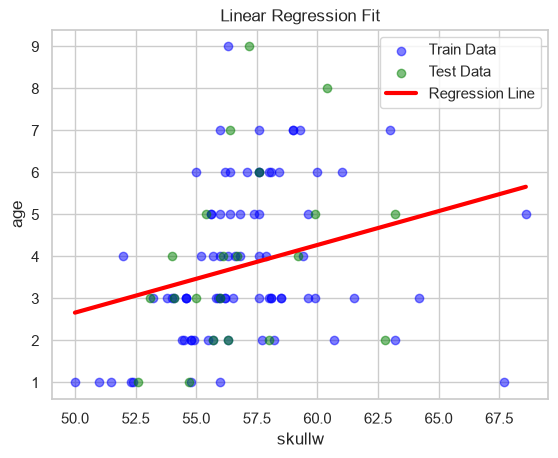

In [22]:
# 1. Plot the actual training data points
plt.scatter(X_train, y_train, color="blue", alpha=0.5, label="Train Data")
plt.scatter(X_test, y_test, color="green", alpha=0.5, label="Test Data")

# 2. Generate a clean sequence of X points from minimum to maximum to form a line
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# 3. Predict the y-values for that line using your trained model
y_line = model.predict(X_line)

# 4. Draw the actual regression line
plt.plot(X_line, y_line, color="red", linewidth=3, label="Regression Line")

# 5. Add labels and show the chart
plt.xlabel("skullw")
plt.ylabel("age")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

/Users/minhquang/Desktop/SS 2026/No-Code-ML-Models-generator/backend/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/minhquang/Desktop/SS 2026/No-Code-ML-Models-generator/backend/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


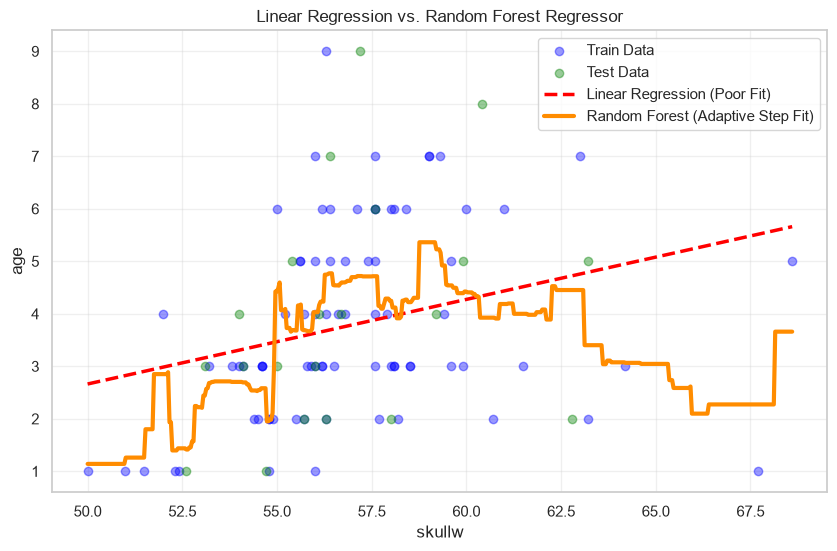

In [23]:
# 1. Train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Setup a dense line range for smooth plotting
X_line = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

# 3. Predict using BOTH models
y_line_linear = model.predict(X_line)  # Your old linear model
y_line_rf = rf_model.predict(X_line)    # The new Random Forest model

# 4. Plot them together to compare
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color="blue", alpha=0.4, label="Train Data")
plt.scatter(X_test, y_test, color="green", alpha=0.4, label="Test Data")

# Draw the straight line vs the adaptive tree line
plt.plot(X_line, y_line_linear, color="red", linewidth=2.5, linestyle="--", label="Linear Regression (Poor Fit)")
plt.plot(X_line, y_line_rf, color="darkorange", linewidth=3, label="Random Forest (Adaptive Step Fit)")

plt.xlabel("skullw")
plt.ylabel("age")
plt.title("Linear Regression vs. Random Forest Regressor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred

array([3.95145626, 4.72491085, 3.69363806, 3.88700171, 4.14481991,
       3.46804714, 3.64529715, 4.7893654 , 3.82254716, 4.33818355,
       3.53250169, 3.32302441, 3.41970623, 3.5808426 , 3.62918351,
       3.67752443, 3.16188803, 3.30691077, 4.25761537, 3.74197897,
       3.08131985])

In [30]:
from sklearn.metrics import mean_squared_error


abs(y_pred - y_test)

array([1.95145626, 2.72491085, 3.30636194, 2.11299829, 0.14481991,
       0.46804714, 0.35470285, 0.2106346 , 5.17745284, 3.66181645,
       1.46749831, 0.32302441, 2.41970623, 1.5808426 , 0.62918351,
       1.67752443, 0.16188803, 0.69308923, 0.74238463, 0.25802103,
       2.08131985])

In [29]:
df_test = pd.DataFrame({
  "y_true": y_test,
  "y_pred": y_pred 
})
df_test

,y_true,y_pred
0,2.0,3.951456
1,2.0,4.724911
2,7.0,3.693638
3,6.0,3.887002
4,4.0,4.144820
5,3.0,3.468047
6,4.0,3.645297
7,5.0,4.789365
8,9.0,3.822547
9,8.0,4.338184
